# 📊 Phân Tích và Làm Sạch Dữ Liệu
## Hệ Thống Gợi Ý Du Lịch Quốc Tế

Notebook này trình bày toàn bộ quá trình:
1. Thu thập và kiểm tra dữ liệu thô (Raw Data)
2. Làm sạch và loại bỏ trùng lặp (Cleaning & Deduplication)
3. Điền giá trị khuyết thiếu (Missing Value Imputation)
4. Tính đặc trưng mới (Feature Engineering)
5. Phân cụm điểm đến (K-Means Clustering)
6. Khai thác luật kết hợp (Apriori Mining)
7. Trực quan hóa kết quả (Visualization)

In [1]:
# ─── Thư viện cần thiết ───
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

# Đường dẫn
BASE_DIR   = Path('.')
RAW_DIR    = BASE_DIR / 'raw'
PROC_DIR   = BASE_DIR / 'processed'

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


---
## 1. Thu Thập Dữ Liệu Thô (Raw Data)

Dữ liệu được thu thập từ các nguồn:
- **Tourist_Destinations.csv** – Kaggle: Tourist Destinations dataset
- **raw_data_India.csv** – Google Maps POI scraping (Ấn Độ)
- **Global_Holidays_2025_2035.csv** – Public Holidays API

In [2]:
# ─── Đọc dữ liệu thô ───
df_raw_dest     = pd.read_csv(RAW_DIR / 'Tourist_Destinations.csv')
df_raw_poi      = pd.read_csv(RAW_DIR / 'raw_data_India.csv')
df_raw_holidays = pd.read_csv(RAW_DIR / 'Global_Holidays_2025_2035.csv')

print('=' * 60)
print('📂 Tourist_Destinations.csv (Điểm đến du lịch)')
print(f'   Kích thước: {df_raw_dest.shape[0]:,} dòng × {df_raw_dest.shape[1]} cột')
print(f'   Cột: {list(df_raw_dest.columns)}')

print()
print('📂 raw_data_India.csv (Điểm tham quan - POI)')
print(f'   Kích thước: {df_raw_poi.shape[0]:,} dòng × {df_raw_poi.shape[1]} cột')
print(f'   Cột: {list(df_raw_poi.columns)}')

print()
print('📂 Global_Holidays_2025_2035.csv (Lịch ngày lễ)')
print(f'   Kích thước: {df_raw_holidays.shape[0]:,} dòng × {df_raw_holidays.shape[1]} cột')
print(f'   Cột: {list(df_raw_holidays.columns)}')
print('=' * 60)

📂 Tourist_Destinations.csv (Điểm đến du lịch)
   Kích thước: 2,000 dòng × 9 cột
   Cột: ['Destination Name', 'Country', 'Continent', 'Type', 'Avg Cost (USD/day)', 'Best Season', 'Avg Rating', 'Annual Visitors (M)', 'UNESCO Site']

📂 raw_data_India.csv (Điểm tham quan - POI)
   Kích thước: 7,856 dòng × 10 cột
   Cột: ['Unnamed: 0', 'place_id', 'name', 'link', 'main_category', 'categories', 'rating', 'reviews', 'address', 'city']

📂 Global_Holidays_2025_2035.csv (Lịch ngày lễ)
   Kích thước: 10,540 dòng × 7 cột
   Cột: ['Country', 'Year', 'Date', 'Holiday_Name', 'Local_Name', 'Type', 'Description']


---
## 2. Kiểm Tra Chất Lượng Dữ Liệu Thô

In [3]:
# ─── 2.1 Xem 5 dòng đầu dữ liệu điểm đến ───
print('📋 5 dòng đầu của Tourist_Destinations.csv:')
df_raw_dest.head()

📋 5 dòng đầu của Tourist_Destinations.csv:


,Destination Name,Country,Continent,Type,Avg Cost (USD/day),Best Season,Avg Rating,Annual Visitors (M),UNESCO Site
0,Serene Temple,Morocco,Africa,Beach,174.84,Summer,4.5,7.45,No
1,Sacred Valley,Germany,Europe,Religious,94.41,Summer,4.6,1.98,No
2,Serene Temple,South Africa,Africa,Adventure,228.96,Summer,4.7,0.70,Yes
3,Sacred Plaza,Australia,Oceania,Nature,120.96,Summer,4.3,2.24,No
4,Golden Ruins,Mexico,North America,Adventure,162.10,Spring,3.9,4.60,No


In [4]:
# ─── 2.2 Thống kê mô tả ───
print('📊 Thống kê mô tả (Tourist_Destinations.csv):')
df_raw_dest.describe()

📊 Thống kê mô tả (Tourist_Destinations.csv):


,Avg Cost (USD/day),Avg Rating,Annual Visitors (M)
count,2000.000000,2000.000000,2000.000000
mean,148.270150,4.494250,5.183250
std,48.934991,0.287704,2.752695
min,30.000000,3.500000,0.500000
25%,115.227500,4.300000,2.760000
50%,148.640000,4.500000,5.235000
75%,180.762500,4.700000,7.510000
max,303.840000,5.000000,10.000000


In [5]:
# ─── 2.3 Kiểm tra giá trị khuyết thiếu ───
def check_missing(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    result = pd.DataFrame({'Số lượng thiếu': missing, 'Tỷ lệ (%)': missing_pct})
    result = result[result['Số lượng thiếu'] > 0].sort_values('Số lượng thiếu', ascending=False)
    print(f'\n🔍 [{name}] Giá trị khuyết thiếu:')
    if result.empty:
        print('   ✅ Không có giá trị khuyết thiếu')
    else:
        print(result.to_string())
    return result

missing_dest     = check_missing(df_raw_dest,     'Tourist_Destinations.csv')
missing_poi      = check_missing(df_raw_poi,      'raw_data_India.csv')
missing_holidays = check_missing(df_raw_holidays, 'Global_Holidays_2025_2035.csv')


🔍 [Tourist_Destinations.csv] Giá trị khuyết thiếu:
   ✅ Không có giá trị khuyết thiếu

🔍 [raw_data_India.csv] Giá trị khuyết thiếu:
               Số lượng thiếu  Tỷ lệ (%)
place_id                 3141      39.98
link                     3141      39.98
reviews                   988      12.58
rating                    988      12.58
categories                 52       0.66
main_category              52       0.66
name                        3       0.04
address                     3       0.04

🔍 [Global_Holidays_2025_2035.csv] Giá trị khuyết thiếu:
             Số lượng thiếu  Tỷ lệ (%)
Local_Name            10540     100.00
Description              55       0.52


In [6]:
# ─── 2.4 Kiểm tra trùng lặp ───
dup_dest = df_raw_dest.duplicated(subset=['Destination Name', 'Country']).sum()
dup_poi  = df_raw_poi.duplicated(subset=['name']).sum() if 'name' in df_raw_poi.columns else 0

print('=' * 55)
print('🔁 KIỂM TRA TRÙNG LẶP (DUPLICATE DETECTION)')
print('=' * 55)
print(f'Tourist_Destinations : {dup_dest:>5} dòng trùng (theo Tên + Quốc gia)')
print(f'raw_data_India (POI) : {dup_poi:>5} dòng trùng (theo Tên POI)')
print()
print(f'📉 Nếu xóa trùng lặp Destinations: {len(df_raw_dest):,} → {len(df_raw_dest) - dup_dest:,} dòng')

🔁 KIỂM TRA TRÙNG LẶP (DUPLICATE DETECTION)
Tourist_Destinations :   743 dòng trùng (theo Tên + Quốc gia)
raw_data_India (POI) :   482 dòng trùng (theo Tên POI)

📉 Nếu xóa trùng lặp Destinations: 2,000 → 1,257 dòng


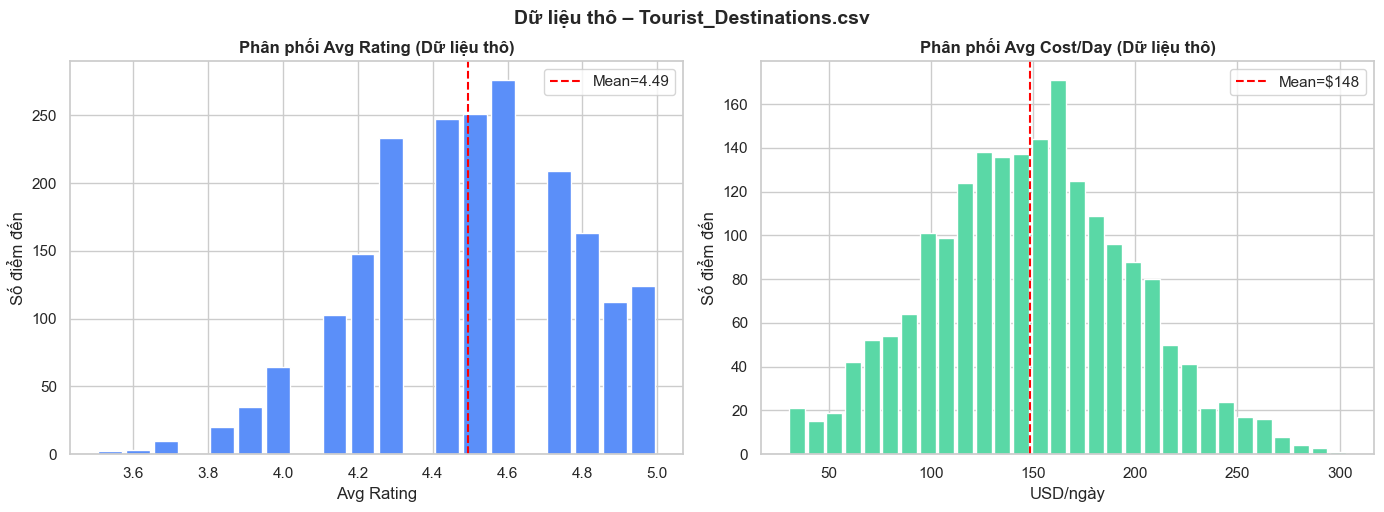

In [7]:
# ─── 2.5 Biểu đồ phân phối rating và chi phí (RAW) ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw_dest['Avg Rating'], bins=20, color='#5B8FF9', edgecolor='white', rwidth=0.85)
axes[0].set_title('Phân phối Avg Rating (Dữ liệu thô)', fontweight='bold')
axes[0].set_xlabel('Avg Rating')
axes[0].set_ylabel('Số điểm đến')
axes[0].axvline(df_raw_dest['Avg Rating'].mean(), color='red', linestyle='--', label=f'Mean={df_raw_dest["Avg Rating"].mean():.2f}')
axes[0].legend()

axes[1].hist(df_raw_dest['Avg Cost (USD/day)'], bins=30, color='#5AD8A6', edgecolor='white', rwidth=0.85)
axes[1].set_title('Phân phối Avg Cost/Day (Dữ liệu thô)', fontweight='bold')
axes[1].set_xlabel('USD/ngày')
axes[1].set_ylabel('Số điểm đến')
axes[1].axvline(df_raw_dest['Avg Cost (USD/day)'].mean(), color='red', linestyle='--', label=f'Mean=${df_raw_dest["Avg Cost (USD/day)"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.suptitle('Dữ liệu thô – Tourist_Destinations.csv', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## 3. Làm Sạch Dữ Liệu (Data Cleaning)
### 3.1 Làm sạch bộ dữ liệu Điểm Đến Du Lịch

In [8]:
# ─── Bước 1: Xóa trùng lặp ───
print('BƯỚC 1: Xóa trùng lặp (Deduplication)')
print(f'  Trước: {len(df_raw_dest):,} dòng')

df_clean = df_raw_dest.drop_duplicates(subset=['Destination Name', 'Country'], keep='first').copy()

print(f'  Sau  : {len(df_clean):,} dòng')
print(f'  ✂️  Đã xóa: {len(df_raw_dest) - len(df_clean):,} dòng trùng lặp')

BƯỚC 1: Xóa trùng lặp (Deduplication)
  Trước: 2,000 dòng
  Sau  : 1,257 dòng
  ✂️  Đã xóa: 743 dòng trùng lặp


In [9]:
# ─── Bước 2: Lọc giá trị không hợp lệ ───
print('BƯỚC 2: Lọc giá trị không hợp lệ (Filtering Invalid Values)')

invalid_rating = df_clean[(df_clean['Avg Rating'] < 1.0) | (df_clean['Avg Rating'] > 5.0)]
invalid_cost   = df_clean[df_clean['Avg Cost (USD/day)'] <= 0]

print(f'  Rating ngoài khoảng [1.0, 5.0]: {len(invalid_rating)} dòng')
print(f'  Chi phí <= 0 USD              : {len(invalid_cost)} dòng')

df_clean = df_clean[
    (df_clean['Avg Rating'] >= 1.0) & (df_clean['Avg Rating'] <= 5.0) &
    (df_clean['Avg Cost (USD/day)'] > 0)
].copy()

print(f'  ✅ Sau lọc: {len(df_clean):,} dòng hợp lệ')

BƯỚC 2: Lọc giá trị không hợp lệ (Filtering Invalid Values)
  Rating ngoài khoảng [1.0, 5.0]: 0 dòng
  Chi phí <= 0 USD              : 0 dòng
  ✅ Sau lọc: 1,257 dòng hợp lệ


In [10]:
# ─── Bước 3: Điền giá trị khuyết thiếu ───
print('BƯỚC 3: Điền giá trị khuyết thiếu (Missing Value Imputation)')

null_visitors = df_clean['Annual Visitors (M)'].isnull().sum()
print(f'  Cột "Annual Visitors (M)" thiếu: {null_visitors} dòng')

if null_visitors > 0:
    median_val = df_clean['Annual Visitors (M)'].median()
    df_clean['Annual Visitors (M)'] = df_clean['Annual Visitors (M)'].fillna(median_val)
    print(f'  → Điền bằng Median = {median_val:.2f} triệu lượt')

print(f'  ✅ Không còn giá trị thiếu ở cột Annual Visitors: {df_clean["Annual Visitors (M)"].isnull().sum()}')

BƯỚC 3: Điền giá trị khuyết thiếu (Missing Value Imputation)
  Cột "Annual Visitors (M)" thiếu: 0 dòng
  ✅ Không còn giá trị thiếu ở cột Annual Visitors: 0


### 3.2 Làm sạch bộ dữ liệu POI (Điểm Tham Quan)

In [11]:
# ─── Làm sạch POI ───
print('LÀM SẠCH POI (Point of Interest)')
print(f'  Trước: {len(df_raw_poi):,} dòng, {len(df_raw_poi.columns)} cột')

# Xóa cột rác
cols_to_drop = [c for c in ['Unnamed: 0', 'link', 'place_id'] if c in df_raw_poi.columns]
df_poi = df_raw_poi.drop(columns=cols_to_drop).copy()
print(f'  → Xóa cột không cần thiết: {cols_to_drop}')

# Chuẩn hóa khoảng trắng
df_poi.columns = df_poi.columns.str.strip()
df_poi['name'] = df_poi['name'].astype(str).str.strip()
df_poi['main_category'] = df_poi['main_category'].astype(str).str.strip()

# Lọc bỏ hàng thiếu rating / review
before_filter = len(df_poi)
df_poi_clean = df_poi.dropna(subset=['rating', 'reviews']).copy()
df_poi_clean = df_poi_clean[df_poi_clean['rating'] >= 1.0].copy()

print(f'  → Loại bỏ hàng thiếu rating/reviews: {before_filter - len(df_poi_clean)} dòng')
print(f'  ✅ Sau làm sạch: {len(df_poi_clean):,} dòng, {len(df_poi_clean.columns)} cột')

LÀM SẠCH POI (Point of Interest)
  Trước: 7,856 dòng, 10 cột
  → Xóa cột không cần thiết: ['Unnamed: 0', 'link', 'place_id']
  → Loại bỏ hàng thiếu rating/reviews: 988 dòng
  ✅ Sau làm sạch: 6,868 dòng, 7 cột


### 3.3 Làm sạch bộ dữ liệu Ngày Lễ

In [12]:
# ─── Làm sạch Holidays ───
print('LÀM SẠCH HOLIDAYS (Lịch ngày lễ quốc tế)')
print(f'  Trước: {len(df_raw_holidays):,} dòng')

df_hol = df_raw_holidays.copy()

# Thêm cột tháng và mùa
df_hol['Date'] = pd.to_datetime(df_hol['Date'], errors='coerce')
df_hol['Holiday_Month'] = df_hol['Date'].dt.month

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df_hol['Holiday_Season'] = df_hol['Holiday_Month'].apply(get_season)

# Điền Local_Name thiếu = Holiday_Name
df_hol['Local_Name'] = df_hol['Local_Name'].fillna(df_hol['Holiday_Name'])
# Điền Description thiếu = chuỗi rỗng
df_hol['Description'] = df_hol['Description'].fillna('')

print(f'  → Thêm cột Holiday_Month và Holiday_Season')
print(f'  → Điền Local_Name và Description bị thiếu')
print(f'  ✅ Sau xử lý: {len(df_hol):,} dòng, {len(df_hol.columns)} cột')
print(f'  Phân bố mùa lễ hội:')
print(df_hol['Holiday_Season'].value_counts().to_frame())

LÀM SẠCH HOLIDAYS (Lịch ngày lễ quốc tế)
  Trước: 10,540 dòng
  → Thêm cột Holiday_Month và Holiday_Season
  → Điền Local_Name và Description bị thiếu
  ✅ Sau xử lý: 10,540 dòng, 9 cột
  Phân bố mùa lễ hội:
                count
Holiday_Season       
Spring           3354
Autumn           2849
Winter           2357
Summer           1980


---
## 4. Feature Engineering – Tính Đặc Trưng Mới

In [13]:
# ─── Phân loại ngân sách ───
def cost_category(cost):
    if cost < 80:   return 'Budget'
    elif cost < 150: return 'Moderate'
    elif cost < 250: return 'Expensive'
    else:            return 'Luxury'

df_clean['Cost_Category'] = df_clean['Avg Cost (USD/day)'].apply(cost_category)
df_clean['Cost_Per_Rating'] = (df_clean['Avg Cost (USD/day)'] / df_clean['Avg Rating']).round(2)

# Phân loại nhóm loại hình
broader_map = {
    'Beach': 'Nature', 'Mountain': 'Nature', 'Wildlife': 'Nature', 'Nature': 'Nature',
    'Urban': 'Modern',  'City': 'Modern',
    'Cultural': 'Heritage', 'Historical': 'Heritage', 'Religious': 'Heritage',
    'Adventure': 'Adventure'
}
df_clean['Broader_Type'] = df_clean['Type'].map(broader_map).fillna('Other')

print('📐 Feature Engineering – Kết quả:')
print()
print('Cost_Category (phân loại ngân sách):')
print(df_clean['Cost_Category'].value_counts().to_frame())
print()
print('Broader_Type (nhóm loại hình):')
print(df_clean['Broader_Type'].value_counts().to_frame())

📐 Feature Engineering – Kết quả:

Cost_Category (phân loại ngân sách):
               count
Cost_Category       
Expensive        585
Moderate         518
Budget           115
Luxury            39

Broader_Type (nhóm loại hình):
              count
Broader_Type       
Heritage        424
Nature          405
Adventure       222
Modern          206


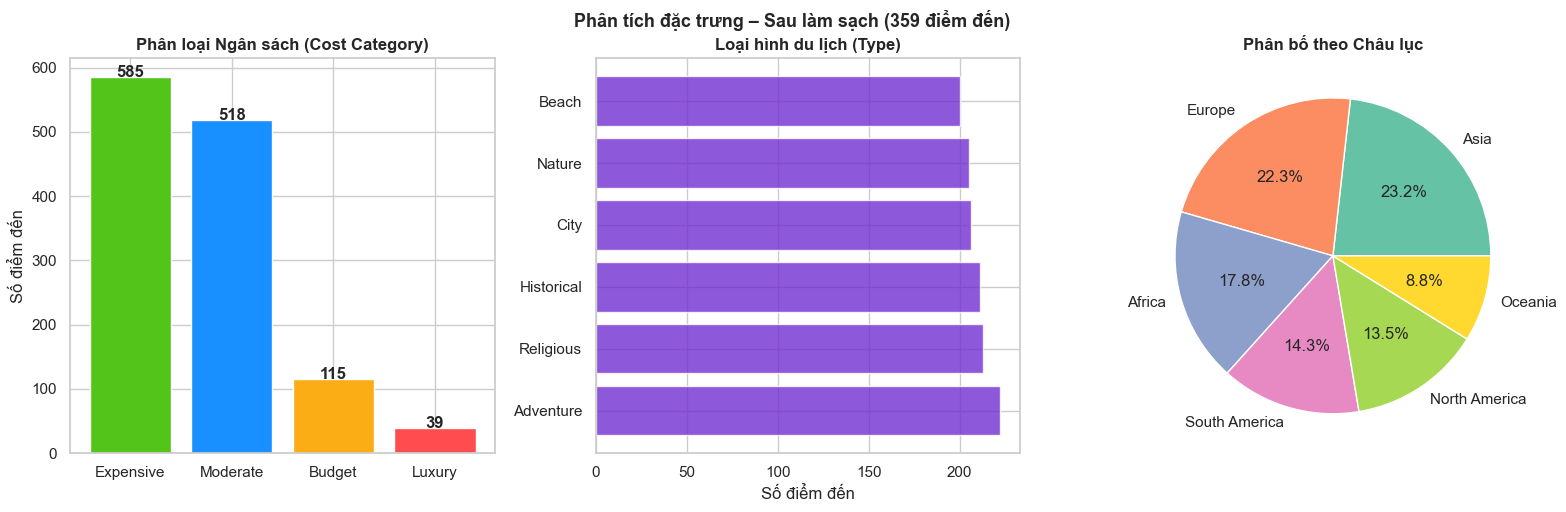

In [14]:
# ─── Biểu đồ phân phối sau làm sạch ───
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cost Category
cost_counts = df_clean['Cost_Category'].value_counts()
colors = ['#52C41A', '#1890FF', '#FAAD14', '#FF4D4F']
axes[0].bar(cost_counts.index, cost_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Phân loại Ngân sách (Cost Category)', fontweight='bold')
axes[0].set_ylabel('Số điểm đến')
for i, v in enumerate(cost_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Type
type_counts = df_clean['Type'].value_counts().head(8)
axes[1].barh(type_counts.index, type_counts.values, color='#722ED1', alpha=0.8)
axes[1].set_title('Loại hình du lịch (Type)', fontweight='bold')
axes[1].set_xlabel('Số điểm đến')

# Continent
cont_counts = df_clean['Continent'].value_counts()
axes[2].pie(cont_counts.values, labels=cont_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(cont_counts)))
axes[2].set_title('Phân bố theo Châu lục', fontweight='bold')

plt.tight_layout()
plt.suptitle('Phân tích đặc trưng – Sau làm sạch (359 điểm đến)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 5. Phân Cụm K-Means (Clustering)
Đọc kết quả đã xử lý từ `destinations_clustered.csv`

In [15]:
# ─── Đọc dữ liệu đã clustering ───
df_clustered = pd.read_csv(PROC_DIR / 'destinations_clustered.csv')
df_profiles  = pd.read_csv(PROC_DIR / 'cluster_profiles.csv')

print('📊 Cluster Profiles (K-Means, K=5):')
print(df_profiles.to_string(index=False))

📊 Cluster Profiles (K-Means, K=5):
 Cluster  Size  Avg_Cost_Per_Day  Avg_Cost_Of_Living_Index  Avg_Restaurant_Price_Index  Avg_Rating Cost_Level
       0    44        222.272727                 99.310455                   94.345000    4.763636  Expensive
       1   106         68.996604                 38.912784                   36.570309    4.701887     Budget
       2    57        151.993158                 32.512281                   24.810526    4.970175  Expensive
       3    27        299.251852                 44.965000                   42.676000    4.770370     Luxury
       4   125        123.207840                 61.213684                   57.561316    4.769600   Moderate


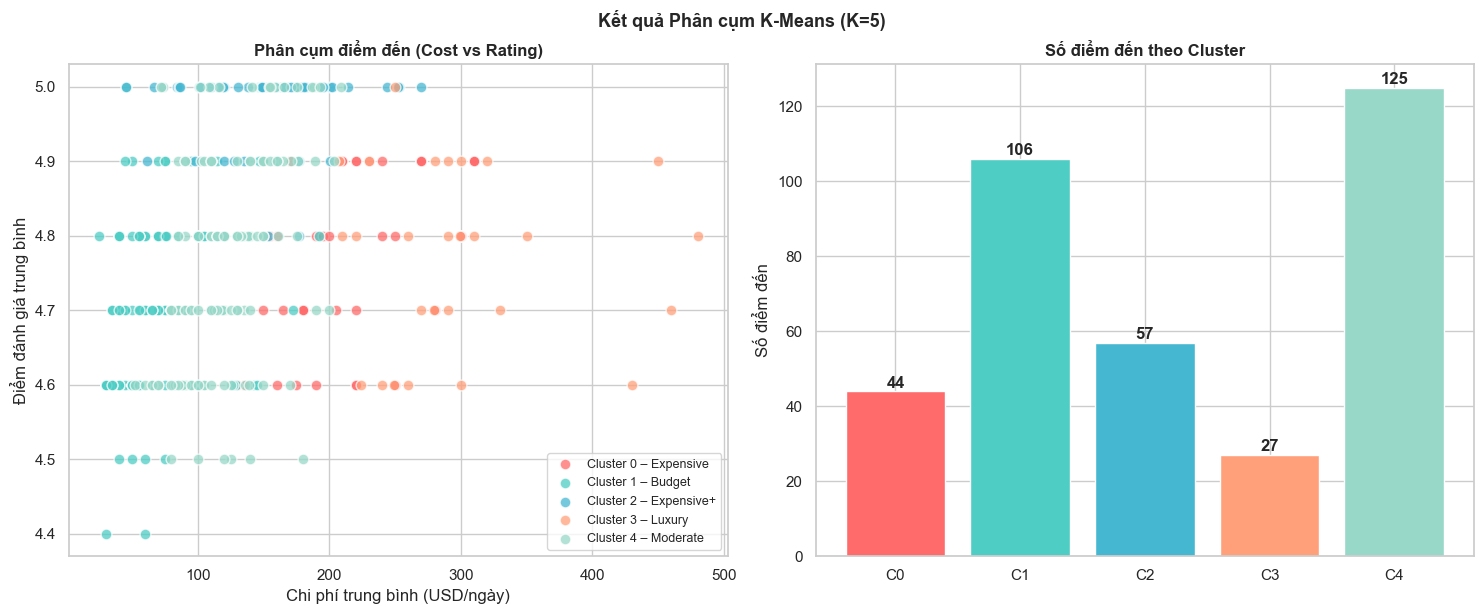

In [16]:
# ─── Biểu đồ Scatter: Cost vs Rating theo Cluster ───
colors_cluster = ['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A','#98D8C8']
cluster_labels_map = {
    0: 'Cluster 0 – Expensive',
    1: 'Cluster 1 – Budget',
    2: 'Cluster 2 – Expensive+',
    3: 'Cluster 3 – Luxury',
    4: 'Cluster 4 – Moderate'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter
for cluster_id in sorted(df_clustered['Cluster'].unique()):
    subset = df_clustered[df_clustered['Cluster'] == cluster_id]
    axes[0].scatter(
        subset['Avg Cost (USD/day)'], subset['Avg Rating'],
        c=colors_cluster[cluster_id],
        label=cluster_labels_map.get(cluster_id, f'Cluster {cluster_id}'),
        alpha=0.75, s=60, edgecolors='white'
    )
axes[0].set_xlabel('Chi phí trung bình (USD/ngày)')
axes[0].set_ylabel('Điểm đánh giá trung bình')
axes[0].set_title('Phân cụm điểm đến (Cost vs Rating)', fontweight='bold')
axes[0].legend(fontsize=9)

# Bar - Size
cluster_sizes = df_clustered['Cluster'].value_counts().sort_index()
bars = axes[1].bar(
    [f'C{i}' for i in cluster_sizes.index],
    cluster_sizes.values,
    color=colors_cluster[:len(cluster_sizes)], edgecolor='white'
)
axes[1].set_title('Số điểm đến theo Cluster', fontweight='bold')
axes[1].set_ylabel('Số điểm đến')
for bar, v in zip(bars, cluster_sizes.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.suptitle('Kết quả Phân cụm K-Means (K=5)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 6. Tạo Ma Trận Giao Dịch (Transaction Matrix)
Dữ liệu đầu vào cho thuật toán Apriori

In [17]:
# ─── Đọc transactions ───
df_trans = pd.read_csv(PROC_DIR / 'transactions.csv')

print('📋 Ma trận giao dịch (Transaction Matrix):')
print(f'  Kích thước : {df_trans.shape[0]:,} giao dịch × {df_trans.shape[1]} item')
print(f'  Giá trị    : True/False (one-hot encoding)')
print()

# Tỷ lệ True của từng nhóm item
groups = {
    'Continent': [c for c in df_trans.columns if c.startswith('Continent:')],
    'Cost':      [c for c in df_trans.columns if c.startswith('Cost:')],
    'Season':    [c for c in df_trans.columns if c.startswith('Season:')],
    'Type':      [c for c in df_trans.columns if c.startswith('Type:')],
}

print('📊 Tỷ lệ xuất hiện (Support) theo nhóm item:')
for group, cols in groups.items():
    print(f'\n  [{group}]')
    for col in cols:
        pct = df_trans[col].mean() * 100
        bar = '█' * int(pct / 2)
        print(f'  {col:<30}: {pct:5.1f}% {bar}')

📋 Ma trận giao dịch (Transaction Matrix):
  Kích thước : 10,050 giao dịch × 95 item
  Giá trị    : True/False (one-hot encoding)

📊 Tỷ lệ xuất hiện (Support) theo nhóm item:

  [Continent]
  Continent:Asia                :  31.1% ███████████████
  Continent:Europe              :  31.6% ███████████████
  Continent:North America       :  10.4% █████
  Continent:South America       :   9.0% ████
  Continent:Africa              :  11.9% █████
  Continent:Oceania             :   6.0% ██

  [Cost]
  Cost:Budget                   :  22.5% ███████████
  Cost:Moderate                 :  41.2% ████████████████████
  Cost:Expensive                :  26.0% █████████████
  Cost:Luxury                   :  10.3% █████

  [Season]
  Season:Spring                 :  26.7% █████████████
  Season:Summer                 :  24.5% ████████████
  Season:Autumn                 :  28.4% ██████████████
  Season:Winter                 :  20.3% ██████████

  [Type]
  Type:Urban                    :   4.8% ██
  T

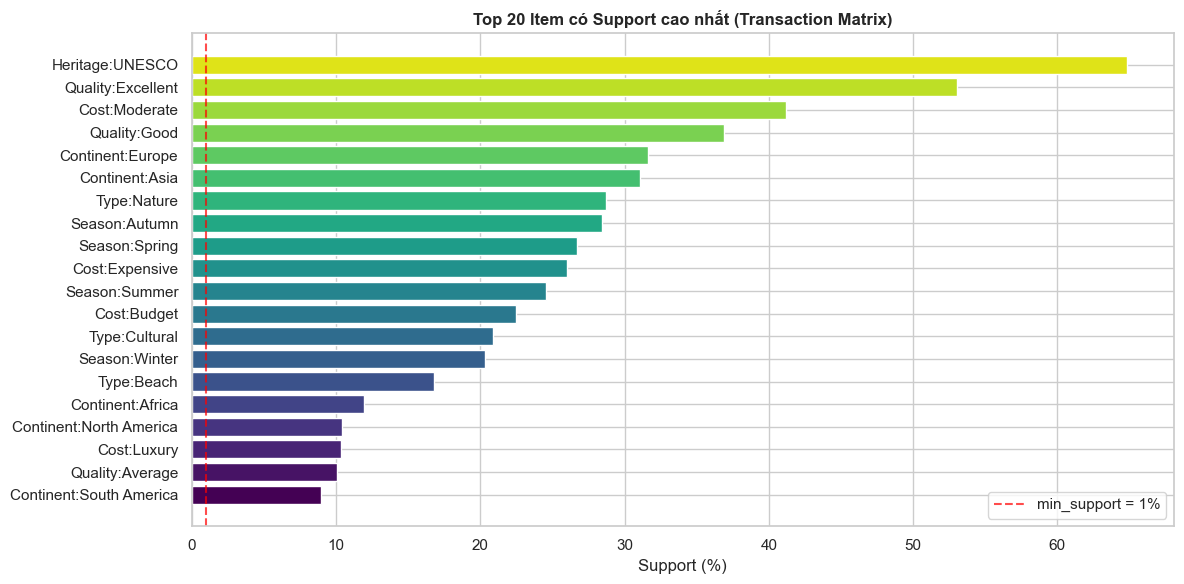

In [18]:
# ─── Biểu đồ support của các item phổ biến ───
support = df_trans.mean().sort_values(ascending=False)

# Chỉ lấy các item không phải Country
support_filtered = support[[c for c in support.index if not c.startswith('Country:')]].head(20)

plt.figure(figsize=(12, 6))
bars = plt.barh(support_filtered.index[::-1], support_filtered.values[::-1] * 100,
                color=plt.cm.viridis([i/20 for i in range(20)]), edgecolor='white')
plt.xlabel('Support (%)')
plt.title('Top 20 Item có Support cao nhất (Transaction Matrix)', fontweight='bold')
plt.axvline(1.0, color='red', linestyle='--', alpha=0.7, label='min_support = 1%')
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Kết Quả Khai Thác Luật Kết Hợp (Apriori Rules)

In [19]:
# ─── Đọc luật kết hợp ───
df_rules = pd.read_csv(PROC_DIR / 'all_rules.csv')

print('📏 Tổng quan luật kết hợp (Association Rules):')
print(f'  Tổng số luật          : {len(df_rules):,}')
print(f'  Luật liên quan điểm đến: {df_rules["is_destination_rule"].sum():,}')
print(f'  Luật khác             : {(~df_rules["is_destination_rule"]).sum():,}')
print()
print(f'  Support  : {df_rules["support"].min():.4f} – {df_rules["support"].max():.4f}')
print(f'  Confidence: {df_rules["confidence"].min():.4f} – {df_rules["confidence"].max():.4f}')
print(f'  Lift      : {df_rules["lift"].min():.2f} – {df_rules["lift"].max():.2f}')
print()
print('Top 5 luật có recommendation_score cao nhất:')
top5 = df_rules.sort_values('recommendation_score', ascending=False).head(5)
print(top5[['antecedents','consequents','confidence','lift','recommendation_score']].to_string(index=False))

📏 Tổng quan luật kết hợp (Association Rules):
  Tổng số luật          : 5,773
  Luật liên quan điểm đến: 1,784
  Luật khác             : 3,989

  Support  : 0.0100 – 0.3606
  Confidence: 0.1000 – 1.0000
  Lift      : 1.00 – 67.00

Top 5 luật có recommendation_score cao nhất:
                         antecedents                          consequents  confidence      lift  recommendation_score
['Cost:Luxury', 'Continent:Oceania']                     ['Country:Fiji']    1.000000 67.000000             67.000000
                    ['Country:Fiji'] ['Cost:Luxury', 'Continent:Oceania']    1.000000 67.000000             67.000000
 ['Cost:Luxury', 'Continent:Europe']              ['Country:Switzerland']    0.916031 61.374046             56.220500
              ['Country:Seychelles']  ['Cost:Luxury', 'Continent:Africa']    1.000000 55.833333             55.833333
             ['Country:Switzerland']  ['Cost:Luxury', 'Continent:Europe']    0.800000 61.374046             49.099237


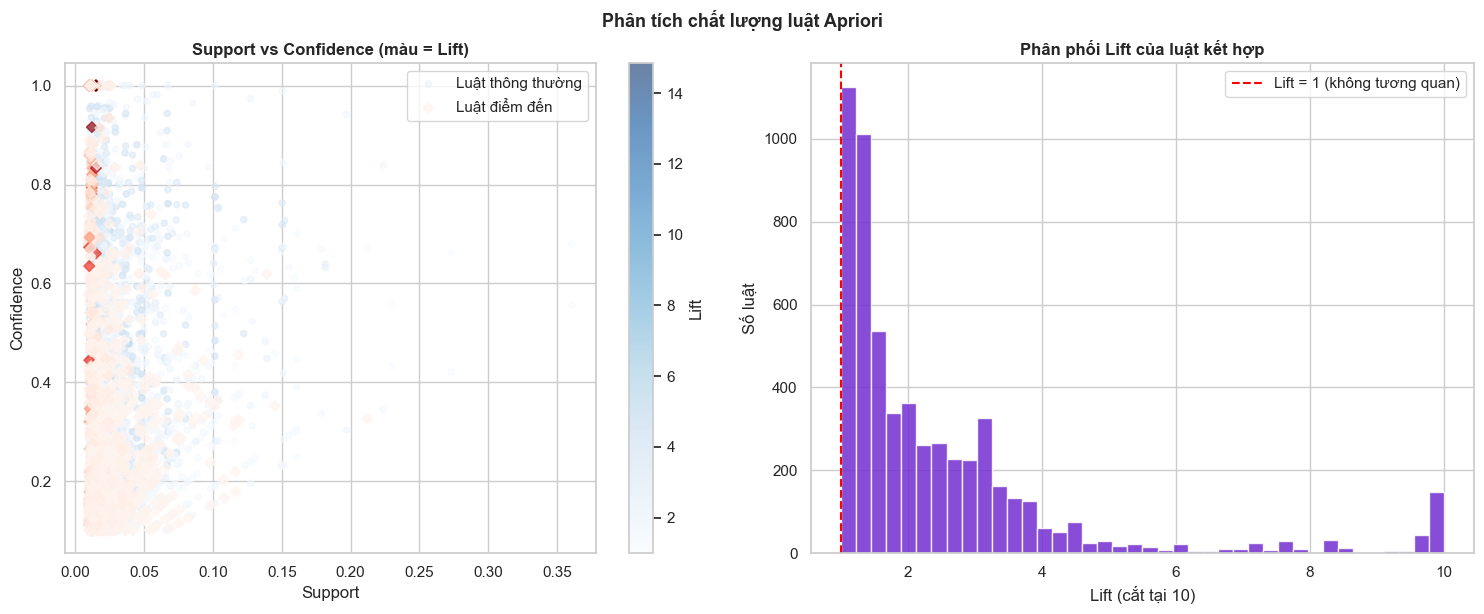

In [20]:
# ─── Biểu đồ Support vs Confidence (colored by Lift) ───
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: Support vs Confidence
dest_rules = df_rules[df_rules['is_destination_rule'] == True]
other_rules = df_rules[df_rules['is_destination_rule'] == False]

sc = axes[0].scatter(other_rules['support'], other_rules['confidence'],
                     c=other_rules['lift'], cmap='Blues', alpha=0.6, s=20, label='Luật thông thường')
axes[0].scatter(dest_rules['support'], dest_rules['confidence'],
                c=dest_rules['lift'], cmap='Reds', alpha=0.7, s=30, label='Luật điểm đến', marker='D')
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Support vs Confidence (màu = Lift)', fontweight='bold')
axes[0].legend()

# Histogram Lift
axes[1].hist(df_rules['lift'].clip(upper=10), bins=40, color='#722ED1', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Lift (cắt tại 10)')
axes[1].set_ylabel('Số luật')
axes[1].set_title('Phân phối Lift của luật kết hợp', fontweight='bold')
axes[1].axvline(1.0, color='red', linestyle='--', label='Lift = 1 (không tương quan)')
axes[1].legend()

plt.tight_layout()
plt.suptitle('Phân tích chất lượng luật Apriori', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 8. Tổng Kết Quá Trình Xử Lý Dữ Liệu

In [21]:
print('=' * 65)
print('  TỔNG KẾT QUÁ TRÌNH PHÂN TÍCH VÀ LÀM SẠCH DỮ LIỆU')
print('=' * 65)

summary = [
    ('Tourist_Destinations.csv (RAW)', f'{len(df_raw_dest):,} dòng × {len(df_raw_dest.columns)} cột'),
    ('  → Xóa trùng lặp',             f'-{dup_dest} dòng'),
    ('  → Lọc invalid rating/cost',   f'-{len(invalid_rating) + len(invalid_cost)} dòng'),
    ('  → Thêm feature mới',          '+Cost_Category, +Broader_Type, +Cost_Per_Rating'),
    ('  → Ghép Country API',          '+32 cột thông tin quốc gia, chi phí sinh hoạt'),
    ('  → K-Means Clustering (K=5)',  'Gán nhãn Cluster cho từng điểm đến'),
    ('destinations_clustered.csv',    f'{len(df_clustered):,} dòng × {len(df_clustered.columns)} cột'),
    ('',                              ''),
    ('raw_data_India.csv (RAW)',       f'{len(df_raw_poi):,} dòng × {len(df_raw_poi.columns)} cột'),
    ('  → Xóa cột rác',               f'-{len(cols_to_drop)} cột'),
    ('  → Lọc thiếu rating/reviews',  f'-{before_filter - len(df_poi_clean):,} dòng'),
    ('poi_clean.csv',                 f'{len(df_poi_clean):,} dòng'),
    ('',                              ''),
    ('Global_Holidays_2025_2035.csv', f'{len(df_raw_holidays):,} dòng'),
    ('  → Thêm cột mùa & tháng',     '+Holiday_Season, +Holiday_Month'),
    ('  → Điền giá trị thiếu',        'Local_Name, Description'),
    ('holidays_clean.csv',            f'{len(df_hol):,} dòng × {len(df_hol.columns)} cột'),
    ('',                              ''),
    ('transactions.csv',              f'{len(df_trans):,} giao dịch × {len(df_trans.columns)} item'),
    ('all_rules.csv (Apriori)',        f'{len(df_rules):,} luật | conf≥0.1 | lift≥1.0'),
]

for label, value in summary:
    if label == '':
        print()
    elif label.startswith('  →'):
        print(f'  {label:<40} {value}')
    elif value == '':
        print(f'  {label}')
    else:
        print(f'▶ {label:<42} {value}')

print()
print('=' * 65)
print('✅ Dữ liệu đã sẵn sàng cho hệ thống gợi ý!')
print('=' * 65)

  TỔNG KẾT QUÁ TRÌNH PHÂN TÍCH VÀ LÀM SẠCH DỮ LIỆU
▶ Tourist_Destinations.csv (RAW)             2,000 dòng × 9 cột
    → Xóa trùng lặp                        -743 dòng
    → Lọc invalid rating/cost              -0 dòng
    → Thêm feature mới                     +Cost_Category, +Broader_Type, +Cost_Per_Rating
    → Ghép Country API                     +32 cột thông tin quốc gia, chi phí sinh hoạt
    → K-Means Clustering (K=5)             Gán nhãn Cluster cho từng điểm đến
▶ destinations_clustered.csv                 359 dòng × 46 cột

▶ raw_data_India.csv (RAW)                   7,856 dòng × 10 cột
    → Xóa cột rác                          -3 cột
    → Lọc thiếu rating/reviews             -988 dòng
▶ poi_clean.csv                              6,868 dòng

▶ Global_Holidays_2025_2035.csv              10,540 dòng
    → Thêm cột mùa & tháng                 +Holiday_Season, +Holiday_Month
    → Điền giá trị thiếu                   Local_Name, Description
▶ holidays_clean.csv               

---
## 9. Ứng Dụng Thuật Toán Vào Dữ Liệu Đã Làm Sạch

Phần này demo **4 thuật toán chính** của hệ thống gợi ý:

| # | Thuật toán | Đầu vào | Đầu ra |
|---|-----------|---------|--------|
| A | **K-Means** | destinations_clustered.csv | Phân cụm 5 nhóm điểm đến |
| B | **Apriori** | transactions.csv | 5.773 luật kết hợp |
| C | **Content-Based (TF-IDF)** | destinations + sở thích | Điểm đến tương đồng |
| D | **Collaborative Filtering** | Ma trận đánh giá user-item | Gợi ý cá nhân hóa |

### A. Thuật Toán K-Means Clustering
> **Mục đích:** Gom nhóm 359 điểm đến thành 5 cụm theo đặc trưng chi phí

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(PROC_DIR / 'destinations_clustered.csv')

# Chọn 4 đặc trưng để phân cụm
features = ['Avg Cost (USD/day)', 'cost_of_living_index',
            'restaurant_price_index', 'local_purchasing_power_index']
df_feat = df[features].fillna(df[features].median())

# Chuẩn hóa (StandardScaler: mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_feat)

print("--- FEATURE SCALING ---")
print(f"Truoc scale: mean={df_feat['Avg Cost (USD/day)'].mean():.1f}, std={df_feat['Avg Cost (USD/day)'].std():.1f}")
print(f"Sau scale  : mean={X_scaled[:,0].mean():.3f}, std={X_scaled[:,0].std():.3f}")

# Elbow Method - chon K toi uu
sse = {}
for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse[k] = km.inertia_

plt.figure(figsize=(8, 4))
plt.plot(list(sse.keys()), list(sse.values()), 'bo-', markersize=8, linewidth=2)
plt.xlabel('K (so cum)')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.title('Elbow Method - Chon K toi uu cho K-Means', fontweight='bold')
plt.axvline(5, color='red', linestyle='--', label='K=5 (chon)') 
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nSSE theo K: { {k: round(v,1) for k,v in sse.items()} }")

In [ ]:
# Chay K-Means voi K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df['Cluster_demo'] = labels

print("--- KET QUA K-MEANS (K=5) ---")
print(f"Inertia (SSE): {kmeans.inertia_:.2f}")
print(f"\nSo diem den theo cum:")
print(df['Cluster_demo'].value_counts().sort_index().to_frame('Count'))
print()

# Profile tung cum
profile = df.groupby('Cluster_demo').agg(
    So_diem_den=('Destination Name', 'count'),
    Chi_phi_TB=('Avg Cost (USD/day)', 'mean'),
    Rating_TB=('Avg Rating', 'mean'),
    Chi_phi_sinh_hoat=('cost_of_living_index', 'mean')
).round(2)
print("Profile tung Cluster:")
print(profile.to_string())

### B. Thuật Toán Apriori – Khai Thác Luật Kết Hợp
> **Mục đích:** Tìm các mẫu hành vi: *nếu người dùng chọn A → họ thường cũng chọn B*

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Doc ma tran giao dich
df_trans = pd.read_csv(PROC_DIR / 'transactions.csv')
print(f"Ma tran giao dich: {df_trans.shape[0]} giao dich x {df_trans.shape[1]} item")

# Buoc 1: Tim frequent itemsets voi min_support=1%
print("\n--- BUOC 1: Tim Frequent Itemsets (min_support=1%) ---")
df_bool = df_trans.astype(bool)
freq_items = apriori(df_bool, min_support=0.01, use_colnames=True)
freq_items['length'] = freq_items['itemsets'].apply(len)
print(f"So itemsets pho bien tim duoc: {len(freq_items)}")
print(f"  1-itemsets: {(freq_items['length']==1).sum()}")
print(f"  2-itemsets: {(freq_items['length']==2).sum()}")
print(f"  3-itemsets: {(freq_items['length']==3).sum()}")
print(f"  4+-itemsets: {(freq_items['length']>=4).sum()}")
print()

# Top 10 itemsets pho bien nhat
top10 = freq_items.sort_values('support', ascending=False).head(10)
print("Top 10 itemsets pho bien nhat:")
for _, row in top10.iterrows():
    items = list(row['itemsets'])
    print(f"  {items} => support={row['support']:.3f}")

In [ ]:
# Buoc 2: Sinh luat ket hop
print("--- BUOC 2: Sinh Luat Ket Hop (min_lift=1.0, min_confidence=0.1) ---")
rules = association_rules(freq_items, metric='lift', min_threshold=1.0)
rules = rules[rules['confidence'] >= 0.1]
print(f"Tong so luat sinh ra: {len(rules)}")

# Tinh recommendation_score
rules['rec_score'] = rules['confidence'] * rules['lift']

print("\n--- TOP 10 LUAT CO REC_SCORE CAO NHAT ---")
top_rules = rules.sort_values('rec_score', ascending=False).head(10)
for _, r in top_rules.iterrows():
    ant = list(r['antecedents'])
    con = list(r['consequents'])
    print(f"  IF {ant}")
    print(f"    THEN {con}")
    print(f"    => support={r['support']:.3f} | conf={r['confidence']:.3f} | lift={r['lift']:.2f} | score={r['rec_score']:.3f}")
    print()

In [ ]:
# Demo: Tra luat theo so thich nguoi dung
def get_matching_rules_demo(preferences, rules_df):
    pref_items = []
    if preferences.get('season'):  pref_items.append(f"Season:{preferences['season']}")
    if preferences.get('budget'):  pref_items.append(f"Cost:{preferences['budget']}")
    if preferences.get('category'): pref_items.append(f"Type:{preferences['category']}")
    
    results = []
    for _, row in rules_df.iterrows():
        ants = list(row['antecedents'])
        if all(a in pref_items for a in ants):
            results.append(row)
    
    results = pd.DataFrame(results)
    if not results.empty:
        results = results.sort_values('rec_score', ascending=False)
    return results

# Test voi so thich: Autumn + Budget
pref = {'season': 'Autumn', 'budget': 'Budget'}
matched = get_matching_rules_demo(pref, rules)
print(f"So thich nguoi dung: {pref}")
print(f"Tim thay {len(matched)} luat khop\n")
print("Top 5 luat goi y:")
for _, r in matched.head(5).iterrows():
    cons = list(r['consequents'])
    print(f"  => {cons}  (conf={r['confidence']:.2f}, lift={r['lift']:.2f})")

### C. Thuật Toán Content-Based Filtering (TF-IDF + Cosine Similarity)
> **Mục đích:** Tìm điểm đến tương đồng dựa trên đặc trưng nội dung (loại hình, mùa, chi phí...)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df_dest = pd.read_csv(PROC_DIR / 'destinations_clustered.csv')
df_dest = df_dest.fillna('')

# Buoc 1: Tao metadata 'soup' cho moi diem den
def create_soup(row):
    parts = [str(row.get('Type','')), str(row.get('Continent','')),
             str(row.get('Best Season','')), str(row.get('Cost_Category','')),
             str(row.get('Country','')), str(row.get('Broader_Type',''))]
    return ' '.join(p for p in parts if p and p != 'nan').lower()

df_dest['soup'] = df_dest.apply(create_soup, axis=1)

print("--- VD SOUP CUA MOT SO DIEM DEN ---")
for _, row in df_dest.head(3).iterrows():
    print(f"  {row['Destination Name']}: '{row['soup']}'")

# Buoc 2: Vecto hoa TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df_dest['soup'])
print(f"\nTF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"So tu vung (vocabulary): {len(vectorizer.vocabulary_)}")

In [ ]:
# Buoc 3: Tim diem den tuong dong
def get_similar_content(dest_name, df, matrix, top_n=5):
    idx_list = df[df['Destination Name'].str.lower() == dest_name.lower()].index
    if len(idx_list) == 0:
        return []
    idx = idx_list[0]
    sim_scores = cosine_similarity(matrix[idx], matrix).flatten()
    sim_indices = np.argsort(sim_scores)[::-1]
    sim_indices = [i for i in sim_indices if i != idx][:top_n]
    result = df.iloc[sim_indices][['Destination Name','Country','Type','Best Season','Cost_Category']].copy()
    result['Cosine_Similarity'] = sim_scores[sim_indices]
    return result

print("--- CONTENT-BASED: Tim diem den tuong dong ---")
test_dest = df_dest['Destination Name'].iloc[0]
print(f"Diem den goc: '{test_dest}'")
print(f"  Type={df_dest.loc[df_dest['Destination Name']==test_dest, 'Type'].values[0]}")
print(f"  Season={df_dest.loc[df_dest['Destination Name']==test_dest, 'Best Season'].values[0]}")
print()
similar = get_similar_content(test_dest, df_dest, tfidf_matrix, top_n=5)
print("Top 5 diem den tuong dong:")
print(similar.to_string(index=False))

In [ ]:
# Buoc 4: Xep hang theo so thich nguoi dung
def rank_by_preference(prefs, df, vectorizer, tfidf_matrix, top_n=8):
    query = ' '.join([str(v) for v in prefs.values() if v]).lower()
    query_vec = vectorizer.transform([query])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    df = df.copy()
    df['content_score'] = scores
    result = df.sort_values('content_score', ascending=False).head(top_n)
    return result[['Destination Name','Country','Type','Best Season','Cost_Category','content_score']]

pref = {'season': 'Summer', 'budget': 'Budget', 'category': 'Beach'}
print(f"So thich nguoi dung: {pref}")
print()
ranked = rank_by_preference(pref, df_dest, vectorizer, tfidf_matrix)
print("Top 8 diem den phu hop nhat (Content-Based):")
print(ranked.to_string(index=False))

### D. Thuật Toán Collaborative Filtering (Item-Based)
> **Mục đích:** Gợi ý dựa trên hành vi đánh giá của nhiều người dùng có sở thích tương tự

In [ ]:
# Tao ma tran danh gia nguoi dung - diem den (User-Item Matrix)
np.random.seed(42)
dest_names = df_dest['Destination Name'].tolist()

# Mo phong 50 nguoi dung danh gia ngau nhien 10-20 diem den
print("--- TAO MA TRAN DANH GIA (User-Item Matrix) ---")
ratings_list = []
for user_id in range(1, 51):
    num_rated = np.random.randint(10, 20)
    rated = np.random.choice(dest_names, num_rated, replace=False)
    for dest in rated:
        rating = round(np.random.uniform(2.5, 5.0), 1)
        ratings_list.append({'user_id': f'User_{user_id}', 'destination': dest, 'rating': rating})

df_ratings = pd.DataFrame(ratings_list)
print(f"Tong so luot danh gia: {len(df_ratings)}")
print(f"So nguoi dung: {df_ratings['user_id'].nunique()}")
print(f"So diem den duoc danh gia: {df_ratings['destination'].nunique()}")
print()

# Tao User-Item matrix
user_item = df_ratings.pivot_table(index='user_id', columns='destination', values='rating').fillna(0)
print(f"User-Item Matrix shape: {user_item.shape}")
print("Mau (5 user x 5 diem den dau):")
print(user_item.iloc[:5, :5].to_string())

In [ ]:
# Tinh Item-Item Similarity
item_sim = cosine_similarity(user_item.T)
item_sim_df = pd.DataFrame(item_sim, index=user_item.columns, columns=user_item.columns)

print("--- ITEM-ITEM SIMILARITY MATRIX ---")
print(f"Shape: {item_sim_df.shape}")

# Demo: Tim diem den tuong dong theo danh gia nguoi dung
sample_dest = user_item.columns[0]
top_similar = item_sim_df[sample_dest].sort_values(ascending=False).iloc[1:6]
print(f"\nTop 5 diem den tuong dong voi '{sample_dest}' (theo pattern danh gia):")
for dest, score in top_similar.items():
    print(f"  {dest:<40} cosine_sim={score:.4f}")

In [ ]:
# Demo: Goi y cho mot nguoi dung cu the
def recommend_for_user(user_id, user_item_matrix, sim_df, top_n=5):
    if user_id not in user_item_matrix.index:
        return []
    user_ratings = user_item_matrix.loc[user_id]
    rated = user_ratings[user_ratings > 0].index.tolist()
    unrated = [d for d in sim_df.index if d not in rated]
    
    preds = {}
    for item in unrated:
        sims = sim_df.loc[item, rated]
        user_r = user_ratings[rated]
        denom = sims.sum()
        preds[item] = np.dot(sims, user_r) / denom if denom > 0 else 0.0
    
    sorted_preds = sorted(preds.items(), key=lambda x: x[1], reverse=True)
    return sorted_preds[:top_n]

test_user = 'User_1'
user_rated = df_ratings[df_ratings['user_id'] == test_user]['destination'].tolist()
print(f"Nguoi dung: {test_user}")
print(f"Da danh gia {len(user_rated)} diem den, vi du: {user_rated[:3]}")
print()
recs = recommend_for_user(test_user, user_item, item_sim_df)
print(f"Top {len(recs)} goi y cho {test_user}:")
for dest, score in recs:
    row = df_dest[df_dest['Destination Name'] == dest]
    if not row.empty:
        r = row.iloc[0]
        print(f"  {dest:<40} pred_score={score:.3f} | {r['Country']} | {r['Type']}")

### E. Kết Hợp Hybrid: Content-Based + Apriori Score
> **Công thức:** `final_score = 0.6 × content_score + 0.4 × apriori_score`

In [ ]:
print("=" * 65)
print("DEMO HYBRID RECOMMENDER")
print("=" * 65)

user_pref = {'season': 'Autumn', 'budget': 'Budget', 'category': 'Cultural'}
print(f"So thich nguoi dung: {user_pref}\n")

# --- Content-Based score ---
query = f"{user_pref['season']} {user_pref['budget']} {user_pref['category']}".lower()
query_vec = vectorizer.transform([query])
cb_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
df_result = df_dest.copy()
df_result['content_score'] = cb_scores

# --- Apriori score ---
matched_rules = get_matching_rules_demo(user_pref, rules)
boosts = {'Budget': 0.0, 'Asia': 0.0, 'Europe': 0.0, 'Cultural': 0.0, 'Heritage': 0.0}

if not matched_rules.empty:
    for _, r in matched_rules.iterrows():
        for con in list(r['consequents']):
            score = r['rec_score']
            if 'Country:' in con:
                country = con.split(':')[1]
                df_result.loc[df_result['Country'] == country, 'apriori_boost'] = score
            elif 'Continent:' in con:
                cont = con.split(':')[1]
                df_result.loc[df_result['Continent'] == cont, 'apriori_boost'] = score * 0.6
            elif 'Type:' in con:
                t = con.split(':')[1]
                df_result.loc[df_result['Type'] == t, 'apriori_boost'] = score * 0.4

if 'apriori_boost' not in df_result.columns:
    df_result['apriori_boost'] = 0.0
df_result['apriori_boost'] = df_result['apriori_boost'].fillna(0.0)

# Normalize apriori score to [0,1]
max_b = df_result['apriori_boost'].max()
df_result['apriori_score'] = df_result['apriori_boost'] / max_b if max_b > 0 else 0.0

# --- Hybrid final score ---
df_result['final_score'] = 0.6 * df_result['content_score'] + 0.4 * df_result['apriori_score']
df_result = df_result.sort_values('final_score', ascending=False).head(10)

print("Top 10 goi y (Hybrid = 0.6*Content + 0.4*Apriori):")
cols = ['Destination Name','Country','Type','Cost_Category','content_score','apriori_score','final_score']
print(df_result[cols].to_string(index=False))

---
## Tổng Kết Pipeline Thuật Toán

```
Dữ liệu thô (RAW)
       ↓  [Làm sạch + Feature Engineering]
destinations_clustered.csv  +  transactions.csv
       ↓                            ↓
  [K-Means K=5]              [Apriori mining]
  5 cụm điểm đến            5.773 luật kết hợp
       ↓                            ↓
  [Content-Based TF-IDF]    [Apriori score]
  content_score              apriori_score
       ↓___________________________|
       ↓
  [Hybrid Formula]
  final = 0.6 × content + 0.4 × apriori
       ↓
  [Collaborative Filtering boost +0.15 nếu có user_id]
       ↓
  Top-N Gợi ý trả về người dùng
```
